## CNNs project - CIFAR-10

###  Overview

**CIFAR-10** is a standard benchmark dataset used for **image classification**, especially for training and evaluating **Convolutional Neural Networks (CNNs)**.

* **Total images:** 60,000
* **Image size:** 32 × 32 pixels
* **Color channels:** 3 (RGB)
* **Classes:** 10
* **Images per class:** 6,000

#### Dataset Split

* **Training set:** 50,000 images
* **Test set:** 10,000 images

#### Classes

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck
---

### Objectives

#### Data Exploration and Understanding

* Gain familiarity with the CIFAR-10 dataset.
* Examine sample images from different classes to understand the data distribution and visual characteristics.

#### Data Preprocessing

* Normalize image pixel values to improve training efficiency and model convergence.
* Transform class labels into one-hot encoded vectors suitable for multi-class classification.
* Apply data augmentation techniques to increase dataset diversity and enhance model generalization.

#### CNN Architecture Design Using Keras

* Develop a Convolutional Neural Network (CNN) specifically suited for the CIFAR-10 dataset using the Keras framework.
* Integrate regularization techniques such as dropout to mitigate overfitting.

#### Model Training

* Train the CNN using the preprocessed dataset.
* Employ callbacks to dynamically adjust the learning rate and implement early stopping, restoring the best-performing model weights.

#### Learning Performance Analysis

* Visualize and analyze training and validation learning curves across epochs to monitor model performance.

#### Model Evaluation

* Evaluate the trained model on unseen test data to assess its accuracy, loss, and overall robustness.

#### Real-World Generalization

* Test the model on an external image not included in the CIFAR-10 dataset to evaluate its real-world predictive capability.




### Import python libraries


In [1]:
import warnings
warnings.simplefilter("ignore")

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split


2026-02-06 14:43:22.975946: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770389003.184490      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770389003.249458      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770389003.773869      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770389003.773920      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770389003.773923      24 computation_placer.cc:177] computation placer alr

**Import the dataset cifar10 for Convolutional project** 

- The data, shuffled and split between train and test sets:

In [2]:
(X_train,y_train),(X_test, y_test) = cifar10.load_data()
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Dataframe test train split size check

In [3]:
print("Train data shape", X_train.shape)
print("Train dataset size:", X_train.shape[0])
print("Test dataset size:", X_test.shape[0])

Train data shape (35000, 32, 32, 3)
Train dataset size: 35000
Test dataset size: 10000


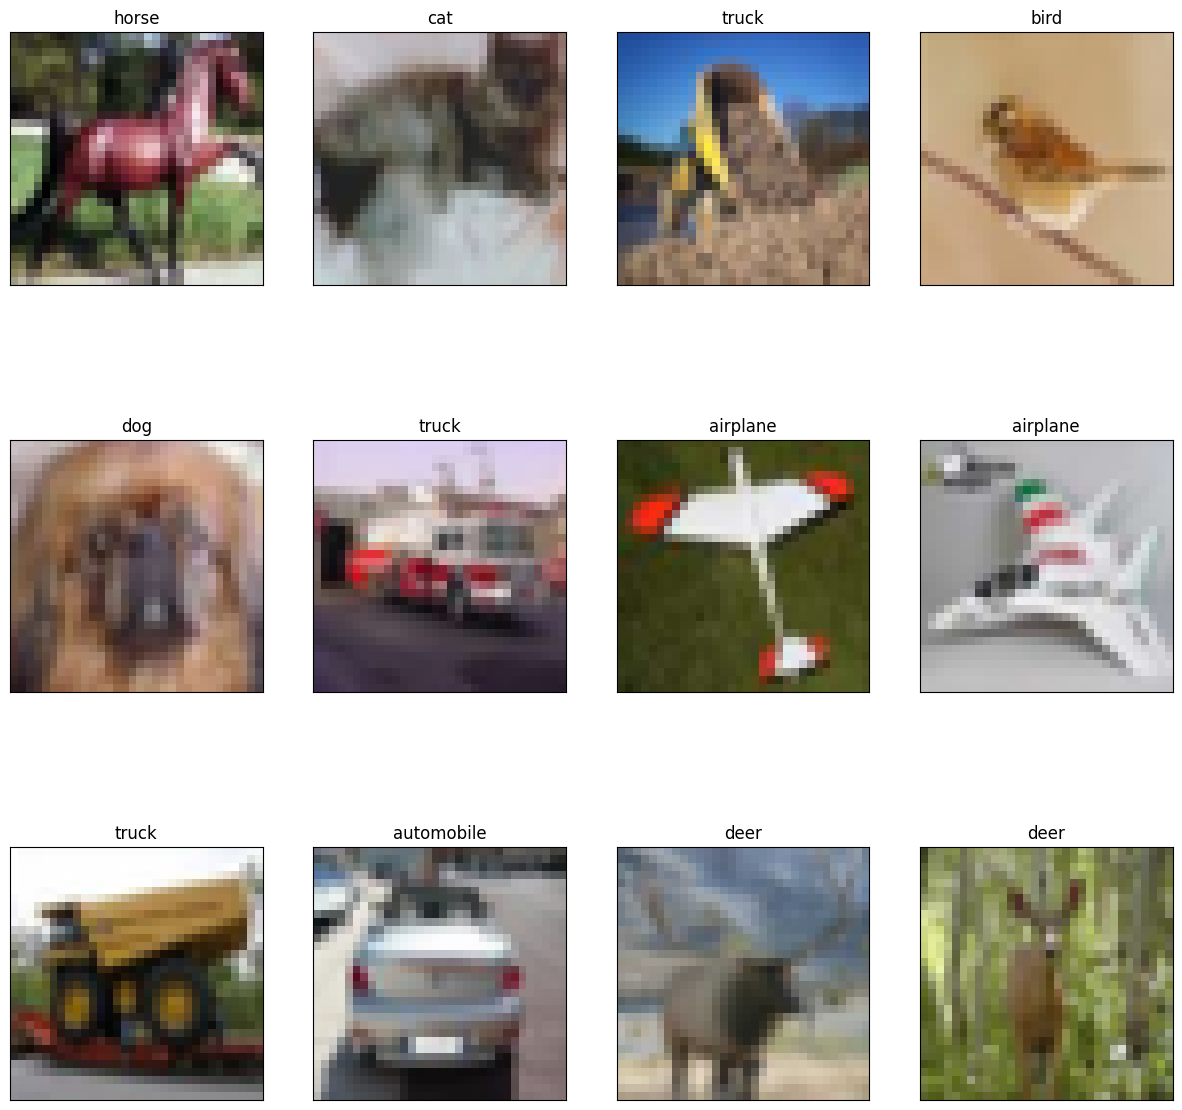

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
               
# Create a new figure
plt.figure(figsize=(15,15))

# Loop over the first 25 images
for i in range(12):
    # Create a subplot for each image
    plt.subplot(3, 4, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(X_train[i])

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [5]:
#Normalized the image data
# Convert pixel values data type to float32
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')
X_valid = X_valid.astype('float32')

# Calculate the mean and standard deviation of the training images
mean = np.mean(X_train)
std  = np.std(X_train)

print("mean value", mean)
print("std value", std)

# Normalize the data
# The tiny value 1e-7 is added to prevent division by zero
X_train = (X_train-mean)/(std+1e-7)
X_test  = (X_test-mean) /(std+1e-7)
X_valid = (X_valid-mean)/(std+1e-7)

#One-Hot encoding label
from keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)
y_test  = to_categorical(y_test, 10)

mean value 120.801025
std value 64.08348


In [6]:
img_size = (100,100, 3)
batch_size = 256
epochs = 100

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)


In [7]:
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = test_datagen.flow(
    X_valid,
    y_valid,
    batch_size=batch_size,
    shuffle=False
)

test_generator = test_datagen.flow(
    X_test,
    y_test,
    batch_size=batch_size,
    shuffle=False
)


### Build convolutional network model

In [8]:
import tensorflow as tf

model = Sequential([
    # Block 1
    Conv2D(128, (3, 3), activation='relu', padding='same',
           input_shape=(32, 32, 3)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Classification head
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()


I0000 00:00:1770389025.387858      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770389025.394177      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,776,330 (33.48 MB)

 Trainable params: 8,776,330 (33.48 MB)

 Non-trainable params: 0 (0.00 B)

### Fit and train the model with adam optimizer

In [9]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,verbose=1)


Epoch 1/100


I0000 00:00:1770389029.578734      71 service.cc:152] XLA service 0x7f51700131c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770389029.578796      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770389029.578802      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770389030.160675      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770389052.123855      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


137/137 ━━━━━━━━━━━━━━━━━━━━ 77s 380ms/step - accuracy: 0.1529 - loss: 2.2205 - val_accuracy: 0.2663 - val_loss: 1.9571
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.2777 - loss: 1.9684 - val_accuracy: 0.3532 - val_loss: 1.7659
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.3390 - loss: 1.7969 - val_accuracy: 0.3987 - val_loss: 1.6690
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.3851 - loss: 1.6971 - val_accuracy: 0.4392 - val_loss: 1.5366
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 24s 173ms/step - accuracy: 0.4140 - loss: 1.6087 - val_accuracy: 0.4693 - val_loss: 1.4657
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 24s 174ms/step - accuracy: 0.4373 - loss: 1.5618 - val_accuracy: 0.4831 - val_loss: 1.4357
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.4495 - loss: 1.5233 - val_accuracy: 0.5024 - val_loss: 1.3943
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - accuracy: 0.4671 - loss: 1.489

### Model Evaluation

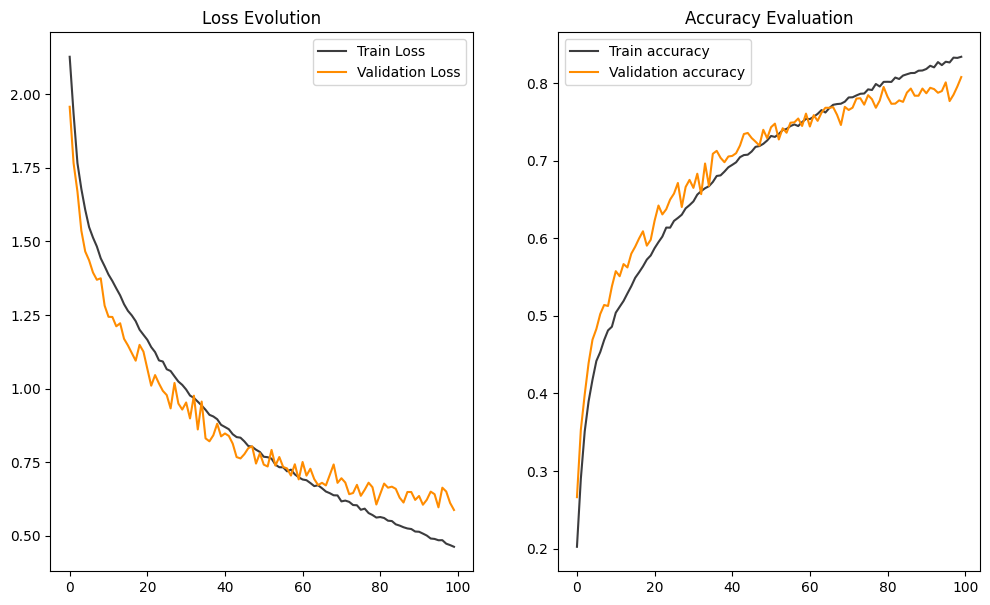

In [10]:
plt.figure(figsize=(12,7))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label='Train Loss', color='#3C3C3E')
plt.plot(model.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy

plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label='Train accuracy', color ='#3C3C3E')
plt.plot(model.history.history['val_accuracy'], label='Validation accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evaluation')
plt.show()

In [11]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, roc_auc_score, roc_curve 
from sklearn import metrics

y_pred_prob_nn_1 = model.predict(X_test)
y_pred_class_nn_1 = (y_pred_prob_nn_1 > 0.5).astype(int)

# Print model performance and plot the roc curve
# Convert probabilities to binary labels
#y_pred_class_nn_1 = (y_pred_prob_nn_1 > 0.5).astype(int)

# Print model performance and plot the roc curve
print(f"The accuracy score of the best model is {accuracy_score(y_test, y_pred_class_nn_1)}\n")
print('roc-auc is {:.3f}'.format(roc_auc_score(y_test, y_pred_prob_nn_1)))

print(metrics.classification_report(y_test, y_pred_class_nn_1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step
The accuracy score of the best model is 0.3313

roc-auc is 0.651
              precision    recall  f1-score   support

           0       0.52      0.53      0.53      1000
           1       0.27      0.93      0.42      1000
           2       0.82      0.03      0.05      1000
           3       0.53      0.15      0.23      1000
           4       0.57      0.01      0.02      1000
           5       0.73      0.24      0.36      1000
           6       0.78      0.06      0.12      1000
           7       0.48      0.43      0.45      1000
           8       0.89      0.13      0.22      1000
           9       0.22      0.81      0.34      1000

   micro avg       0.33      0.33      0.33     10000
   macro avg       0.58      0.33      0.27     10000
weighted avg       0.58      0.33      0.27     10000
 samples avg       0.33      0.33      0.33     10000



### Load the test image from github

(np.float64(-0.5), np.float64(258.5), np.float64(193.5), np.float64(-0.5))

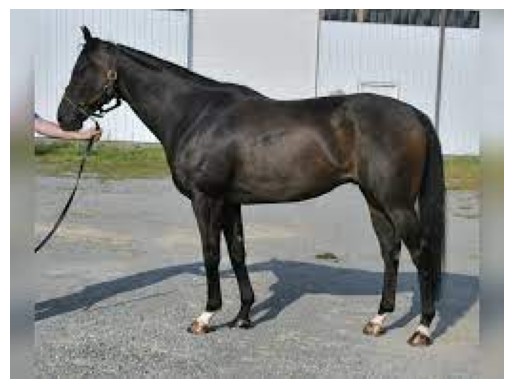

In [12]:
import cv2
import urllib.request
import matplotlib.pyplot as plt

#image from the link
url = "https://raw.githubusercontent.com/JoshuaKab/Deeplearning/main/horse.jpg"
filename = "horse.jpg"

# Download image
urllib.request.urlretrieve(url, filename)

# Read image
img = cv2.imread(filename)

# Convert BGR → RGB (OpenCV uses BGR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display
plt.imshow(img_rgb)
plt.axis("off")


In [13]:
# Resize it to 32x32 pixels
image = cv2.resize(img, (32,32))

# Normalize the image
image = (image-mean)/(std+1e-7)

# Add an extra dimension because the model expects a batch of images
image = image.reshape((1, 32,32, 3))

In [14]:
prediction = model.predict(image)

predicted_class = prediction.argmax()

print('Predicted class: ', class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
Predicted class:  horse


## As you can see the model has performed well and the prediction is accurate.

## Summary
In this project, we built and trained a Convolutional Neural Network (CNN) to classify images from the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 50,000 training images and 10,000 test images. The classes include airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships, and trucks.

### Recommendation
Based on the results, the model performed well on the CIFAR-10 dataset. Here are some recommendations for further improvement:

1. Hyperparameter Tuning:

Experiment with different hyperparameters such as learning rate, batch size, and number of epochs to find the optimal settings.
Use techniques like grid search or random search for hyperparameter optimization.
2. Model Architecture:

Try deeper and more complex architectures such as ResNet, VGG, or Inception to improve accuracy.
Experiment with different activation functions and regularization techniques.

3. Data Augmentation:

Explore additional data augmentation techniques such as vertical flips, color jittering, and random cropping.
Use more aggressive augmentation to further increase the variability of the training set.

4. Transfer Learning:

Utilize pre-trained models on larger datasets (e.g., ImageNet) and fine-tune them on the CIFAR-10 dataset.
This can help improve performance, especially if the dataset is small.

5. Ensemble Methods:

Combine predictions from multiple models to create an ensemble, which can improve overall accuracy and robustness.